Imports and Initialization

In [1]:
import os
os.environ['PYTHONHASHSEED'] = '0'

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (roc_auc_score, classification_report,confusion_matrix, ConfusionMatrixDisplay)
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA, KernelPCA
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import NMF

import random

random.seed(0)
np.random.seed(0)

In [4]:
import re                                  # library for regular expression operations
import string                              # for string operations

In [5]:
import tensorflow as tf
tf.random.set_seed(0)

In [6]:
import nltk

from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer

import spacy
from spacy.matcher import Matcher
from spacy.pipeline import EntityRuler

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

nltk.download("punkt")
nltk.download("punkt_tab")  
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")
nltk.download("averaged_perceptron_tagger_eng")

[nltk_data] Downloading package punkt to /usr/local/lib/python3.13/site-packages/nltk...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /usr/local/lib/python3.13/site-packages/nltk...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /usr/local/lib/python3.13/site-packages/nltk...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /usr/local/lib/python3.13/site-packages/nltk...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /usr/local/lib/python3.13/site-packages/nltk...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /usr/local/lib/python3.13/site-packages/nltk...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]

True

In [7]:
nlp = spacy.load("en_core_web_sm")

Data Imports

In [8]:
import kagglehub

In [9]:
path = kagglehub.dataset_download("thedevastator/nlp-mental-health-conversations")

In [10]:
df = pd.read_csv(path+'/train.csv')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3512 entries, 0 to 3511
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Context   3512 non-null   object
 1   Response  3508 non-null   object
dtypes: object(2)
memory usage: 55.0+ KB


In [12]:
df.head(5)

,Context,Response
0,I'm going through some things with my feelings...,"If everyone thinks you're worthless, then mayb..."
1,I'm going through some things with my feelings...,"Hello, and thank you for your question and see..."
2,I'm going through some things with my feelings...,First thing I'd suggest is getting the sleep y...
3,I'm going through some things with my feelings...,Therapy is essential for those that are feelin...
4,I'm going through some things with my feelings...,I first want to let you know that you are not ...


In [13]:
df[df.duplicated()]

,Context,Response
1856,"I self-harm, and I stop for awhile. Then when ...","In a way, self-harm can present somewhat like ..."
1857,"I self-harm, and I stop for awhile. Then when ...",Self-harm has a way of becoming a go-to method...
1858,After he got home from the hospital he was ang...,"Hello, and thank you for your question. This i..."
1859,After he got home from the hospital he was ang...,This is actually more common then we often rea...
1860,After he got home from the hospital he was ang...,I'm thankful to read your husband found care a...
...,...,...
3499,I just feel sad all the time and I don't like ...,Understandably the idea of someone who tries t...
3500,I don't know how to tell someone how I feel ab...,"""Practice makes perfect""!Simply by expressing ..."
3505,I start counseling/therapy in a few days (I'm ...,Hi there ! As someone who has practiced as a ...
3506,My ex-wife married and used me to have a child...,The thing that confuses a child the most is fo...


In [14]:
df.isnull().sum()

Context     0
Response    4
dtype: int64

Quick EDA

In [15]:
print(f"\nTotal rows: {len(df)}")
print(f"Unique contexts: {df['Context'].nunique()}")
print(f"Average responses per context: {len(df) / df['Context'].nunique():.1f}")


Total rows: 3512
Unique contexts: 995
Average responses per context: 3.5


In [16]:
df['ctx_len'] = df['Context'].str.split().str.len()
df['resp_len'] = df['Response'].str.split().str.len()

print("\nContext length (words):")
print(df['ctx_len'].describe())
print("\nResponse length (words):")
print(df['resp_len'].describe())


Context length (words):
count    3512.000000
mean       55.180809
std        48.275077
min         5.000000
25%        28.000000
50%        46.000000
75%        68.000000
max       526.000000
Name: ctx_len, dtype: float64

Response length (words):
count    3508.000000
mean      177.203820
std       120.665564
min         1.000000
25%        94.000000
50%       145.000000
75%       221.000000
max       939.000000
Name: resp_len, dtype: float64


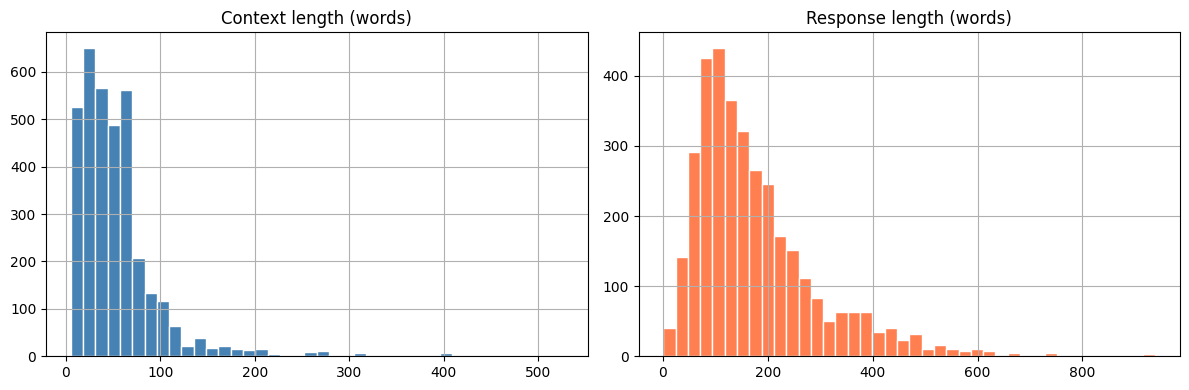

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['ctx_len'].hist(bins=40, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title("Context length (words)")
df['resp_len'].hist(bins=40, ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title("Response length (words)")
plt.tight_layout()
plt.savefig("length_distributions.png", dpi=150)
plt.show()

In [18]:
from collections import Counter
def tokenise(text):
    return re.findall(r'\b[a-z]+\b', str(text).lower())

all_words = [w for text in df['Context'] for w in tokenise(text)]
print(f"\nVocab size (Context): {len(set(all_words))}")
print("Top 20 words:", Counter(all_words).most_common(20))


Vocab size (Context): 3589
Top 20 words: [('i', 16243), ('and', 6722), ('to', 6446), ('my', 4685), ('a', 4533), ('me', 3135), ('the', 3062), ('he', 2949), ('have', 2743), ('it', 2697), ('t', 2587), ('of', 2262), ('in', 2202), ('m', 2161), ('with', 2140), ('is', 2087), ('but', 2080), ('that', 1977), ('for', 1731), ('she', 1605)]


Vanilla Sentiment Analysis (using VADER)

In [19]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [20]:
analyzer = SentimentIntensityAnalyzer()

def vader_compound(text):
    if pd.isna(text):
        return 0.0
    return analyzer.polarity_scores(text)["compound"]

df["Sentiment"] = df["Context"].apply(vader_compound)

def label_from_compound(c):
    if c >= 0:
        return "positive"
    else:
        return "negative"

df["vader_sentiment"] = df["Sentiment"].apply(label_from_compound)
df.head(2)

,Context,Response,ctx_len,resp_len,Sentiment,vader_sentiment
0,I'm going through some things with my feelings...,"If everyone thinks you're worthless, then mayb...",60,163.0,-0.9349,negative
1,I'm going through some things with my feelings...,"Hello, and thank you for your question and see...",60,367.0,-0.9349,negative


vader_sentiment
negative    2205
positive    1307
Name: count, dtype: int64


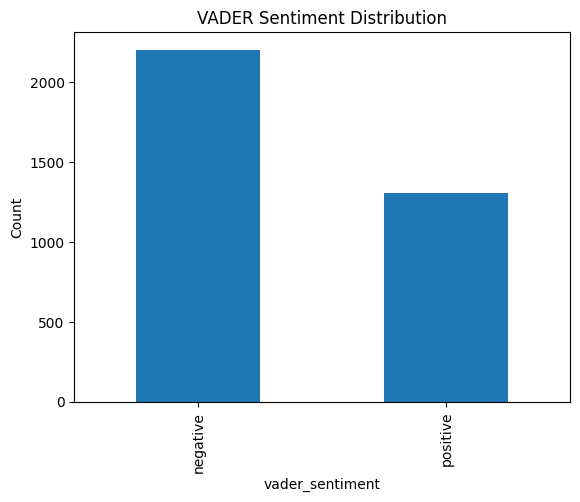

In [21]:
sent_counts = df["vader_sentiment"].value_counts()
print(sent_counts)

sent_counts.plot(kind="bar")
plt.title("VADER Sentiment Distribution")
plt.ylabel("Count")
plt.show()


Emotion Detection

In [22]:
from transformers import pipeline

In [23]:
contexts = df['Context']

# Load pre-trained emotion detection model
emotion_model = pipeline('sentiment-analysis', model='j-hartmann/emotion-english-distilroberta-base')

# Analyze emotions in 'Context'
emotions = contexts.apply(lambda x: emotion_model(x)[0]['label'])

# Add detected emotions as a new column
df['Detected_Emotion'] = emotions


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (641 > 512). Running this sequence through the model will result in indexing errors


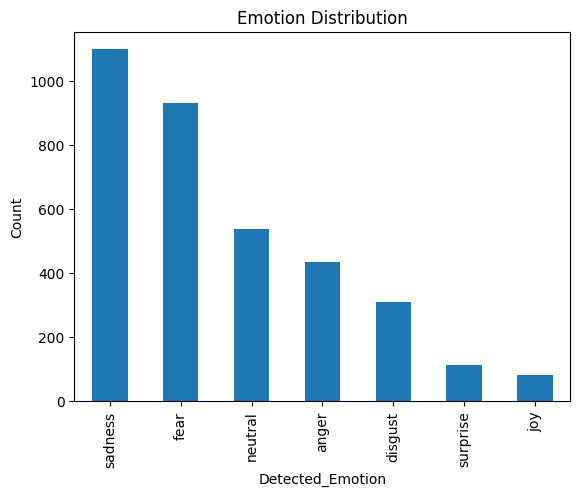

In [24]:
sent_counts = df['Detected_Emotion'].value_counts()
sent_counts.plot(kind="bar")
plt.title("Emotion Distribution")
plt.ylabel("Count")
plt.show()

Structured Information (Using spaCy)

In [25]:
from spacy.matcher import Matcher
from spacy.tokens import Span

In [26]:
def analyze_request(text: str) -> dict:
    doc = nlp(text)

    # Tokens & lemmas (with stopword flags)
    tokens = [t.text for t in doc]
    lemmas = [t.lemma_ for t in doc]
    stop_flags = [t.is_stop for t in doc]
    pos_tags = [f"{t.text}/{t.pos_}" for t in doc]

    # Sentence segmentation
    sents = [s.text for s in doc.sents]

    # Noun chunks (good for quick subject/object)
    chunks = [chunk.text for chunk in doc.noun_chunks]

    # Named Entities (LOC, GPE, MONEY, DATE, ORG, etc.)
    ents = [f"{ent.text}<{ent.label_}>" for ent in doc.ents]


    return {
        "text": text,
        "sentences": sents,
        "tokens": tokens,
        "lemmas": lemmas,
        "stopword_flags": stop_flags,
        "pos_tags": pos_tags,
        "noun_chunks": chunks,
        "entities": ents
    }

In [27]:
df['results_ctx'] = df["Context"].apply(analyze_request)

In [28]:
df.head(2)

,Context,Response,ctx_len,resp_len,Sentiment,vader_sentiment,Detected_Emotion,results_ctx
0,I'm going through some things with my feelings...,"If everyone thinks you're worthless, then mayb...",60,163.0,-0.9349,negative,sadness,{'text': 'I'm going through some things with m...
1,I'm going through some things with my feelings...,"Hello, and thank you for your question and see...",60,367.0,-0.9349,negative,sadness,{'text': 'I'm going through some things with m...


Cleaning Text

In [29]:
from nltk.tokenize import word_tokenize
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

lemmatizer = WordNetLemmatizer()

def clean_text(text):
    # Convert to string
    text = str(text)
    # Convert to lowercase
    text = text.lower()
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    # Tokenize text
    tokens = word_tokenize(text)
    # Remove stop words
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]
    # Lemmatize tokens
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    # Join tokens back into a string
    return ' '.join(tokens) 

In [30]:
df["clean_text"] = df["Context"].apply(clean_text)

In [31]:
df[['Context', 'clean_text']]

,Context,clean_text
0,I'm going through some things with my feelings...,im going thing feeling barely sleep nothing th...
1,I'm going through some things with my feelings...,im going thing feeling barely sleep nothing th...
2,I'm going through some things with my feelings...,im going thing feeling barely sleep nothing th...
3,I'm going through some things with my feelings...,im going thing feeling barely sleep nothing th...
4,I'm going through some things with my feelings...,im going thing feeling barely sleep nothing th...
...,...,...
3507,My grandson's step-mother sends him to school ...,grandson stepmother sends school pink barbie b...
3508,My boyfriend is in recovery from drug addictio...,boyfriend recovery drug addiction recently got...
3509,The birth mother attempted suicide several tim...,birth mother attempted suicide several time pr...
3510,I think adult life is making him depressed and...,think adult life making depressed often sleep ...


Text Vectorization and Test-Train Split

In [32]:
tfidf = TfidfVectorizer(min_df=1, ngram_range=(1, 2))
X_tfidf = tfidf.fit_transform(df["clean_text"])
print("TF-IDF shape:", X_tfidf.shape)

TF-IDF shape: (3512, 21453)


In [33]:
le = LabelEncoder()
df['Detected_Emotion'] = le.fit_transform(df['Detected_Emotion'])

In [34]:
y = df['Detected_Emotion']

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size = 0.2, stratify=y, random_state=0)

Establishing a Baseline: Naive Bayes

In [36]:
MB = MultinomialNB(alpha=1)
MB.fit(X_train,y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [37]:
Pred_y_nb = MB.predict(X_test)
y_pred_proba_nb = MB.predict_proba(X_test)

In [38]:
print(classification_report(y_test, Pred_y_nb,
      target_names=le.classes_.astype(str)))

              precision    recall  f1-score   support

       anger       1.00      0.63      0.77        87
     disgust       1.00      0.55      0.71        62
        fear       0.93      0.96      0.94       186
         joy       1.00      0.18      0.30        17
     neutral       1.00      0.81      0.89       108
     sadness       0.67      1.00      0.80       220
    surprise       1.00      0.30      0.47        23

    accuracy                           0.83       703
   macro avg       0.94      0.63      0.70       703
weighted avg       0.88      0.83      0.82       703



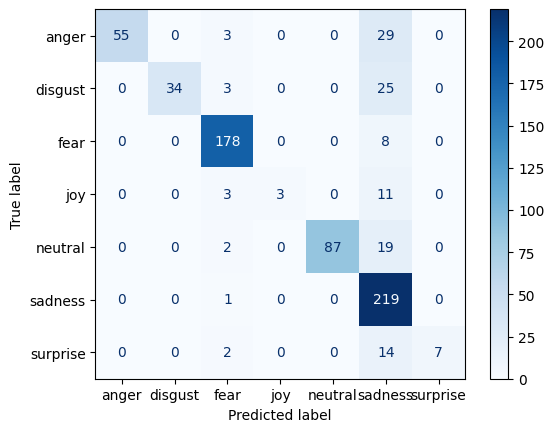

In [39]:
cm_nb = confusion_matrix(y_test, Pred_y_nb)
ConfusionMatrixDisplay(cm_nb, display_labels=le.classes_.astype(str)).plot(cmap='Blues')
plt.show()

Random Forests

In [40]:
model_rf = RandomForestClassifier(class_weight='balanced', n_estimators = 4000)
model_rf.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",4000
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metri

In [41]:
Pred_y_rf = model_rf.predict(X_test)
y_pred_proba_rf = model_rf.predict_proba(X_test)

In [42]:
print(classification_report(y_test, Pred_y_rf,
      target_names=le.classes_.astype(str)))

              precision    recall  f1-score   support

       anger       0.99      0.92      0.95        87
     disgust       1.00      0.92      0.96        62
        fear       0.96      0.98      0.97       186
         joy       1.00      1.00      1.00        17
     neutral       0.99      0.92      0.95       108
     sadness       0.92      0.99      0.95       220
    surprise       0.90      0.78      0.84        23

    accuracy                           0.96       703
   macro avg       0.97      0.93      0.95       703
weighted avg       0.96      0.96      0.96       703



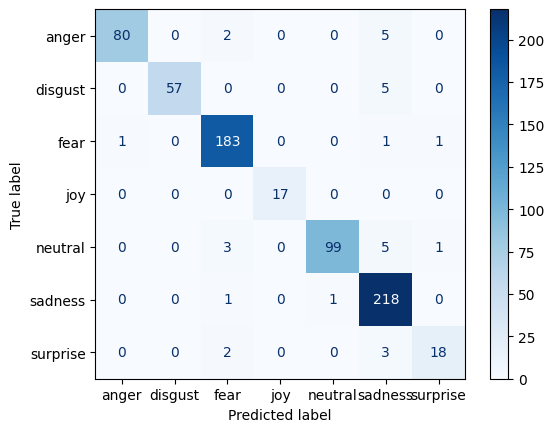

In [43]:
cm_rf = confusion_matrix(y_test, Pred_y_rf)
ConfusionMatrixDisplay(cm_rf, display_labels=le.classes_.astype(str)).plot(cmap='Blues')
plt.show()

Linear SVMs

In [44]:
linear_pipeline = Pipeline([
    ('svm', SVC(kernel='linear', random_state=0, probability=True))
])

param_grid_linear = {
    'svm__C': [0.001, 0.01, 0.1, 1, 10, 100]
}

grid_linear = GridSearchCV(linear_pipeline, param_grid_linear, 
                                cv=5, scoring='accuracy', verbose=1)
grid_linear.fit(X_train,y_train)

best_linear = grid_linear.best_estimator_

print("Best C:", grid_linear.best_params_['svm__C'])
print("Best CV Accuracy: {:.3f}".format(grid_linear.best_score_))



Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best C: 10
Best CV Accuracy: 0.928


In [45]:
print(classification_report(y_test, best_linear.predict(X_test), target_names=le.classes_.astype(str)))

              precision    recall  f1-score   support

       anger       0.99      0.94      0.96        87
     disgust       1.00      0.92      0.96        62
        fear       0.96      0.97      0.97       186
         joy       1.00      1.00      1.00        17
     neutral       0.97      0.92      0.94       108
     sadness       0.92      0.99      0.95       220
    surprise       0.90      0.78      0.84        23

    accuracy                           0.95       703
   macro avg       0.96      0.93      0.95       703
weighted avg       0.96      0.95      0.95       703



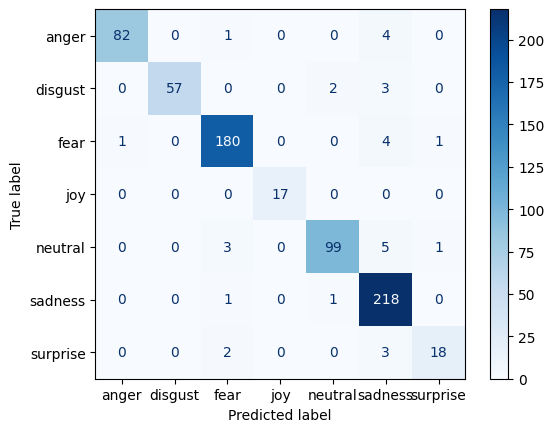

In [46]:
cm_lsvm = confusion_matrix(y_test, best_linear.predict(X_test))
ConfusionMatrixDisplay(cm_lsvm, display_labels=le.classes_.astype(str)).plot(cmap='Blues')
plt.show()

RBF SVM

In [47]:
rbf_pipeline = Pipeline([
    ('svm', SVC(kernel='rbf', random_state=0, probability=True))
])

param_grid_rbf = {
    'svm__C': [0.001, 0.01, 0.1, 1, 10, 100]
}

grid_rbf = GridSearchCV(rbf_pipeline, param_grid_rbf, 
                                cv=5, scoring='accuracy', verbose=1)
grid_rbf.fit(X_train,y_train)

best_rbf = grid_rbf.best_estimator_

print("Best C:", grid_rbf.best_params_['svm__C'])
print("Best CV Accuracy: {:.3f}".format(grid_rbf.best_score_))



Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best C: 10
Best CV Accuracy: 0.916


In [48]:
print(classification_report(y_test, best_rbf.predict(X_test), target_names=le.classes_.astype(str)))

              precision    recall  f1-score   support

       anger       0.99      0.90      0.94        87
     disgust       1.00      0.92      0.96        62
        fear       0.99      0.97      0.98       186
         joy       1.00      1.00      1.00        17
     neutral       0.99      0.92      0.95       108
     sadness       0.88      1.00      0.94       220
    surprise       0.90      0.78      0.84        23

    accuracy                           0.95       703
   macro avg       0.96      0.93      0.94       703
weighted avg       0.95      0.95      0.95       703



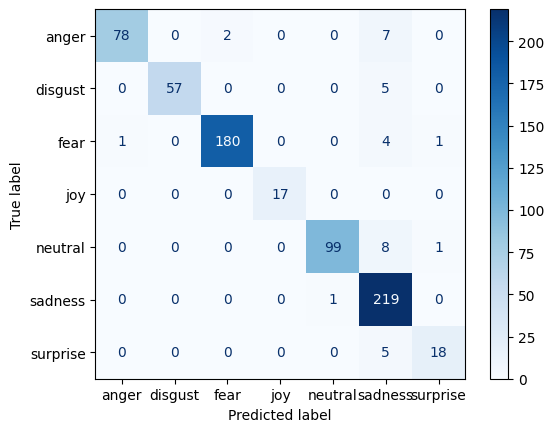

In [49]:
cm_rbf = confusion_matrix(y_test, best_rbf.predict(X_test))
ConfusionMatrixDisplay(cm_rbf, display_labels=le.classes_.astype(str)).plot(cmap='Blues')
plt.show()

LSTM

In [50]:
import tensorflow as tf
from tensorflow.keras.layers import LSTM, Embedding, SpatialDropout1D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping

In [51]:
from sklearn.utils import class_weight
weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(weights))

print(class_weights)

{0: np.float64(1.1564429806504735), 1: np.float64(1.6180875576036866), 2: np.float64(0.5379165070854078), 3: np.float64(5.9893390191897655), 4: np.float64(0.9310573417301956), 5: np.float64(0.45704523267165637), 6: np.float64(4.361801242236025)}


In [52]:
def build_lstm(vocab_size, embedding_dim=64, max_len=50):
    model = Sequential([
        # maps token integers to dense vectors
        Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
        SpatialDropout1D(0.2),
        
        # sequence modelling
        LSTM(128, return_sequences=True),
        Dropout(0.2),
        
        LSTM(64),
        Dropout(0.2),
        
        # classification head
        Dense(32, activation='relu'),
        Dense(7, activation='softmax')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [53]:
MAX_VOCAB = 10000
MAX_LEN   = 60  
EMBED_DIM = 64

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Tokenise contexts
tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer.fit_on_texts(df['Context'])
sequences = tokenizer.texts_to_sequences(df['Context'])
print(np.percentile([len(s) for s in sequences], [50, 90, 95, 99]))
X_seq = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')



[ 46.    98.   136.35 272.56]


In [54]:
X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(X_seq, y, random_state= 0, test_size=0.2, stratify = y)

In [55]:
def build_lstm(vocab_size=10000, embedding_dim=64, max_len=600):
    model = Sequential([
        # maps token integers to dense vectors
        Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
        SpatialDropout1D(0.2),
        
        # sequence modelling
        
        LSTM(64, return_sequences=True),
        Dropout(0.2),
        
        LSTM(32),
        Dropout(0.2),
        
        # classification head
        Dense(32, activation='relu'),
        Dense(7, activation='softmax')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [56]:
model_lstm = build_lstm()
model_lstm.build(input_shape=(None, 64))  # None = batch size, 50 = max_len
print(model_lstm.summary())

/usr/local/lib/python3.13/site-packages/keras/src/layers/core/embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 64, 64)         │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 64, 64)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 686,727 (2.62 MB)

 Trainable params: 686,727 (2.62 MB)

 Non-trainable params: 0 (0.00 B)

None


In [57]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    mode='min',            
    restore_best_weights=True
)

history_lstm = model_lstm.fit(
    X_train_seq, y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=2,
    class_weight = class_weights
)

Epoch 1/200
71/71 - 3s - 49ms/step - accuracy: 0.1954 - loss: 1.8961 - val_accuracy: 0.1619 - val_loss: 1.8953
Epoch 2/200
71/71 - 1s - 19ms/step - accuracy: 0.2737 - loss: 1.7761 - val_accuracy: 0.3452 - val_loss: 1.6131
Epoch 3/200
71/71 - 1s - 19ms/step - accuracy: 0.3031 - loss: 1.6814 - val_accuracy: 0.3968 - val_loss: 1.5499
Epoch 4/200
71/71 - 1s - 19ms/step - accuracy: 0.3881 - loss: 1.4132 - val_accuracy: 0.4893 - val_loss: 1.3282
Epoch 5/200
71/71 - 1s - 19ms/step - accuracy: 0.4806 - loss: 1.2249 - val_accuracy: 0.5214 - val_loss: 1.1940
Epoch 6/200
71/71 - 1s - 19ms/step - accuracy: 0.5701 - loss: 1.0434 - val_accuracy: 0.5516 - val_loss: 1.0998
Epoch 7/200
71/71 - 1s - 19ms/step - accuracy: 0.6288 - loss: 0.9577 - val_accuracy: 0.6228 - val_loss: 0.9705
Epoch 8/200
71/71 - 1s - 19ms/step - accuracy: 0.6377 - loss: 0.8892 - val_accuracy: 0.5943 - val_loss: 1.0225
Epoch 9/200
71/71 - 1s - 19ms/step - accuracy: 0.7014 - loss: 0.7886 - val_accuracy: 0.6548 - val_loss: 0.9189
E

In [58]:
Pred_y_lstm= model_lstm.predict(X_test_seq)


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


In [59]:
pred_nn_lstm = np.argmax(Pred_y_lstm, axis=1)

print(classification_report(y_test, pred_nn_lstm,  zero_division=0, target_names=le.classes_.astype(str)))

              precision    recall  f1-score   support

       anger       0.77      0.84      0.80        87
     disgust       0.86      0.87      0.86        62
        fear       0.97      0.92      0.95       186
         joy       0.94      1.00      0.97        17
     neutral       0.91      0.92      0.91       108
     sadness       0.91      0.93      0.92       220
    surprise       0.94      0.74      0.83        23

    accuracy                           0.90       703
   macro avg       0.90      0.89      0.89       703
weighted avg       0.91      0.90      0.91       703



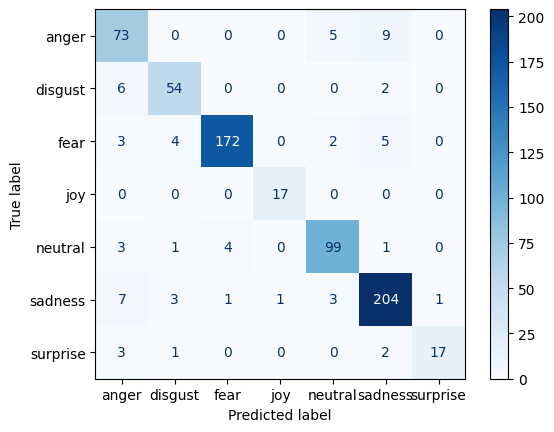

In [60]:
cmlstm = confusion_matrix(y_test, pred_nn_lstm)
ConfusionMatrixDisplay(cmlstm, display_labels=le.classes_.astype(str)).plot(cmap='Blues')
plt.show()


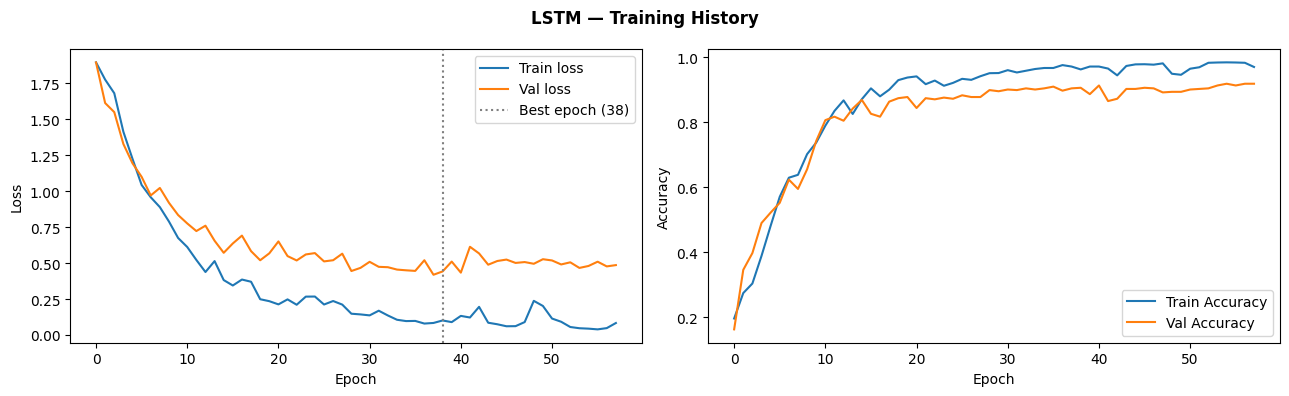

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history_lstm.history['loss'],     label='Train loss')
axes[0].plot(history_lstm.history['val_loss'], label='Val loss')
best_epoch_lstm = np.argmin(history_lstm.history['val_loss']) + 1
axes[0].axvline(x=best_epoch_lstm, color='grey', linestyle=':', label=f'Best epoch ({best_epoch_lstm})')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history_lstm.history['accuracy'],     label='Train Accuracy')
axes[1].plot(history_lstm.history['val_accuracy'], label='Val Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.suptitle('LSTM — Training History', fontweight='bold')
plt.tight_layout()
plt.show()

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


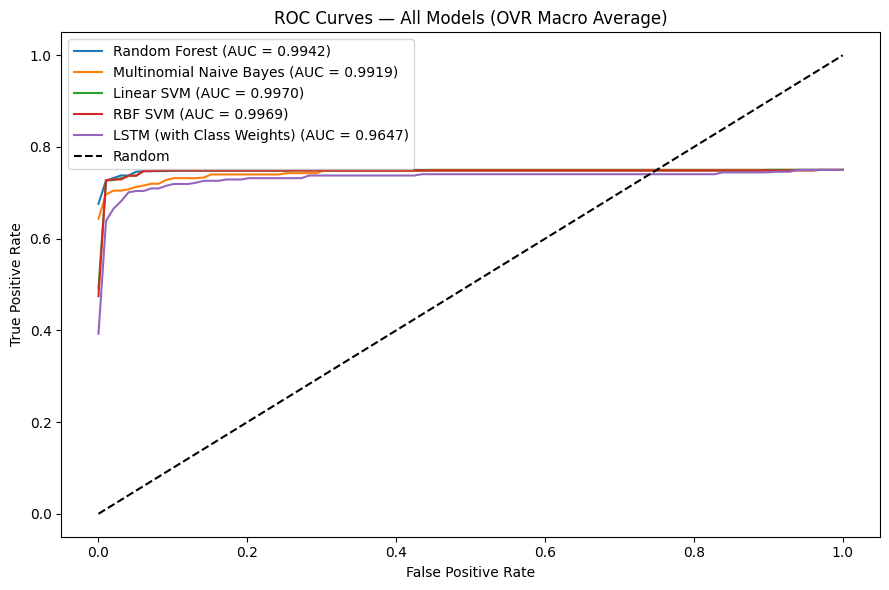

In [62]:
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize

y_bin = label_binarize(y_test, classes=[0,1,2,3])

models = {
    'Random Forest':           (model_rf,   X_test),
    'Multinomial Naive Bayes': (MB,          X_test),
    'Linear SVM': (best_linear, X_test),
    'RBF SVM': (best_rbf, X_test),
    'LSTM (with Class Weights)':                    (model_lstm,  X_test_seq)
}

plt.figure(figsize=(9, 6))

for name, (model, X_feat) in models.items():
    proba = model.predict(X_feat) if isinstance(model, tf.keras.Model) \
            else model.predict_proba(X_feat)
    auc = roc_auc_score(y_test, proba, multi_class='ovr')
    mean_fpr = np.linspace(0, 1, 100)
    mean_tpr = np.zeros(100)
    for i in range(3):
        fpr, tpr, _ = roc_curve(y_bin[:, i], proba[:, i])
        mean_tpr += np.interp(mean_fpr, fpr, tpr)
    mean_tpr /= 4
    plt.plot(mean_fpr, mean_tpr, label=f'{name} (AUC = {auc:.4f})')

plt.plot([0,1],[0,1],'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models (OVR Macro Average)')
plt.legend()
plt.tight_layout()
plt.show()

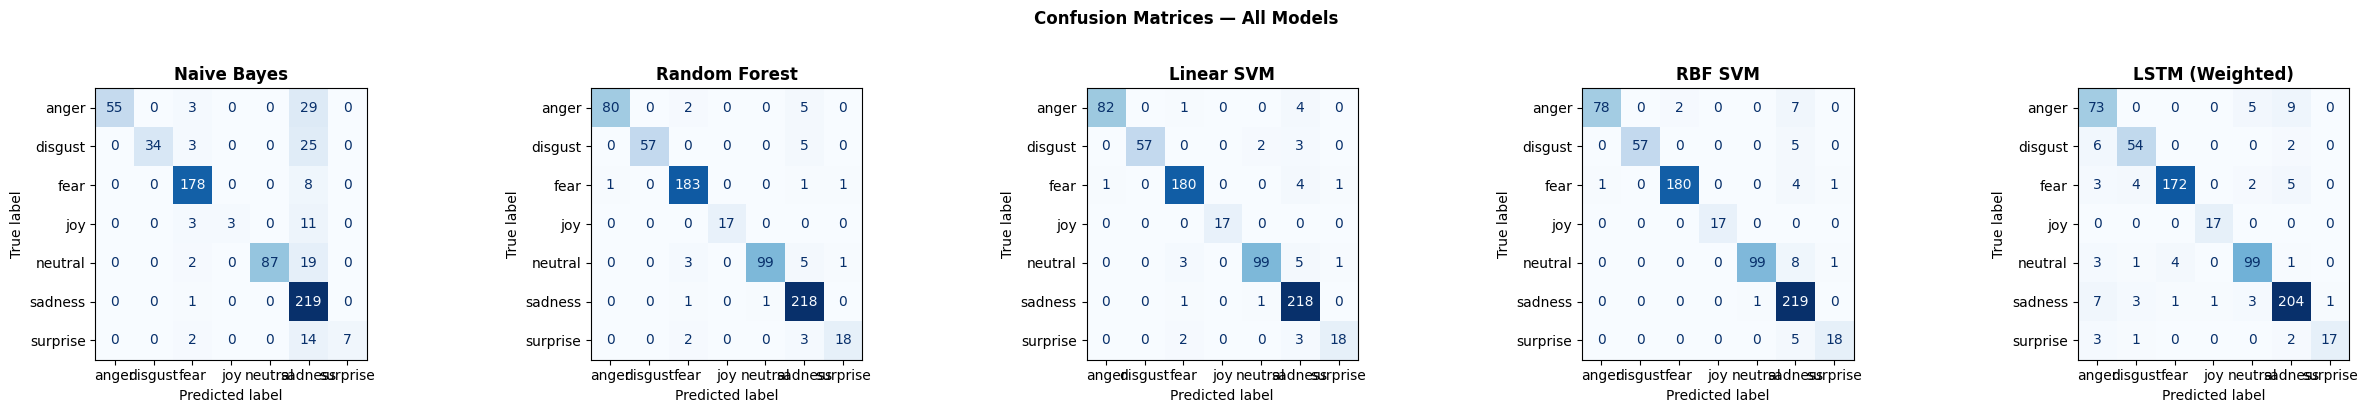

In [63]:
predictions = {
    'Naive Bayes':    Pred_y_nb,
    'Random Forest':  Pred_y_rf,
    'Linear SVM': best_linear.predict(X_test),
    'RBF SVM': best_rbf.predict(X_test),
    'LSTM (Weighted)':           pred_nn_lstm,
}

fig, axes = plt.subplots(1, 5, figsize=(25, 4))
axes = axes.flatten()

for ax, (name, preds) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, preds)
    ConfusionMatrixDisplay(cm, display_labels=le.classes_.astype(str)).plot(
        cmap='Blues', ax=ax, colorbar=False
    )
    ax.set_title(name, fontweight='bold')


plt.suptitle('Confusion Matrices — All Models', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Fine-tuning Mental BERT

In [64]:
from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification, Trainer, TrainingArguments
import torch
from torch.utils.data import Dataset

In [65]:
from huggingface_hub import login
login(token="hf_")

In [143]:
tokenizer = AutoTokenizer.from_pretrained("mental/mental-bert-base-uncased")
model = AutoModelForSequenceClassification.from_pretrained("mental/mental-bert-base-uncased", num_labels=7)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: mental/mental-bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those 

In [144]:
sample = tokenizer(
    "I feel hopeless and don't know what to do",
    padding='max_length',
    truncation=True,
    max_length=128,
    return_tensors='pt'
)
print(sample.keys())         # input_ids, attention_mask, token_type_ids
print(sample['input_ids'].shape)   # (1, 128)

KeysView({'input_ids': tensor([[  101,  1045,  2514, 20625,  1998,  2123,  1005,  1056,  2113,  2054,
          2000,  2079,   102,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,

In [145]:
feature = df['Context']
target = y

np.unique(target)

array([0, 1, 2, 3, 4, 5, 6])

In [146]:
feat_train, feat_test, label_train, label_test = train_test_split(feature, target, random_state=0, stratify = target, test_size = 0.2)

In [147]:
class MentalHealthTestDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
        
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx])
        
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt",
        )
        
        item = {k: v.squeeze(0) for k, v in encoding.items()}
        item["labels"] = torch.tensor(label, dtype=torch.long)
        return item

train_dataset = MentalHealthTestDataset(
    texts=feat_train.tolist(),
    labels=label_train.tolist(),
    tokenizer=tokenizer,
    max_length=128,
)


len(train_dataset)

2809

In [148]:
test_dataset = MentalHealthTestDataset(
    texts=feat_test.tolist(),
    labels=label_test.tolist(),
    tokenizer=tokenizer,
    max_length=128,
)

In [149]:
training_args = TrainingArguments(
    output_dir='./results/MentalH',  # output directory for model checkpoints
    num_train_epochs=3,              # total number of training epochs
    per_device_train_batch_size=8,   # batch size per device during training
    warmup_steps=500,                # number of warmup steps for learning rate scheduler
    weight_decay=0.01,               # strength of weight decay
    logging_dir='./logs',            # directory for storing logs
    logging_steps=10,
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [150]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

trainer.train()

/usr/local/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
10,1.911367
20,1.915783
30,1.903278
40,1.858629
50,1.819156
60,1.745362
70,1.612955
80,1.622463
90,1.528647
100,1.511257


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1056, training_loss=0.523912016506956, metrics={'train_runtime': 841.9471, 'train_samples_per_second': 10.009, 'train_steps_per_second': 1.254, 'total_flos': 554334100473600.0, 'train_loss': 0.523912016506956, 'epoch': 3.0})

In [151]:
preds = trainer.predict(test_dataset)
y_pred_BERT = np.argmax(preds.predictions, axis=1)

/usr/local/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


In [152]:
print(classification_report(y_test, y_pred_BERT, zero_division=0,target_names=le.classes_.astype(str)))

              precision    recall  f1-score   support

       anger       0.99      0.98      0.98        87
     disgust       1.00      0.98      0.99        62
        fear       0.97      0.99      0.98       186
         joy       1.00      1.00      1.00        17
     neutral       0.97      0.96      0.97       108
     sadness       0.97      1.00      0.98       220
    surprise       0.94      0.74      0.83        23

    accuracy                           0.98       703
   macro avg       0.98      0.95      0.96       703
weighted avg       0.98      0.98      0.98       703



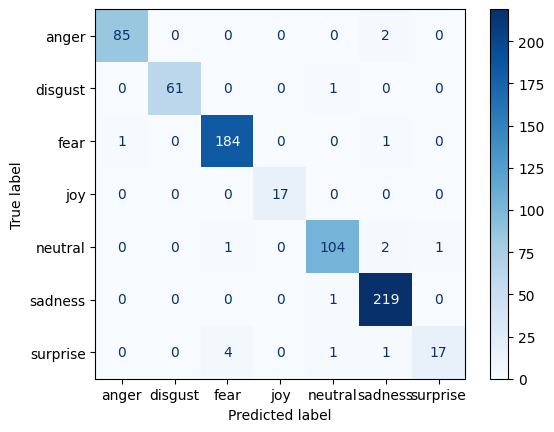

In [153]:
cmbert = confusion_matrix(y_test, y_pred_BERT)
ConfusionMatrixDisplay(cmbert, display_labels=le.classes_.astype(str)).plot(cmap='Blues')
plt.show()


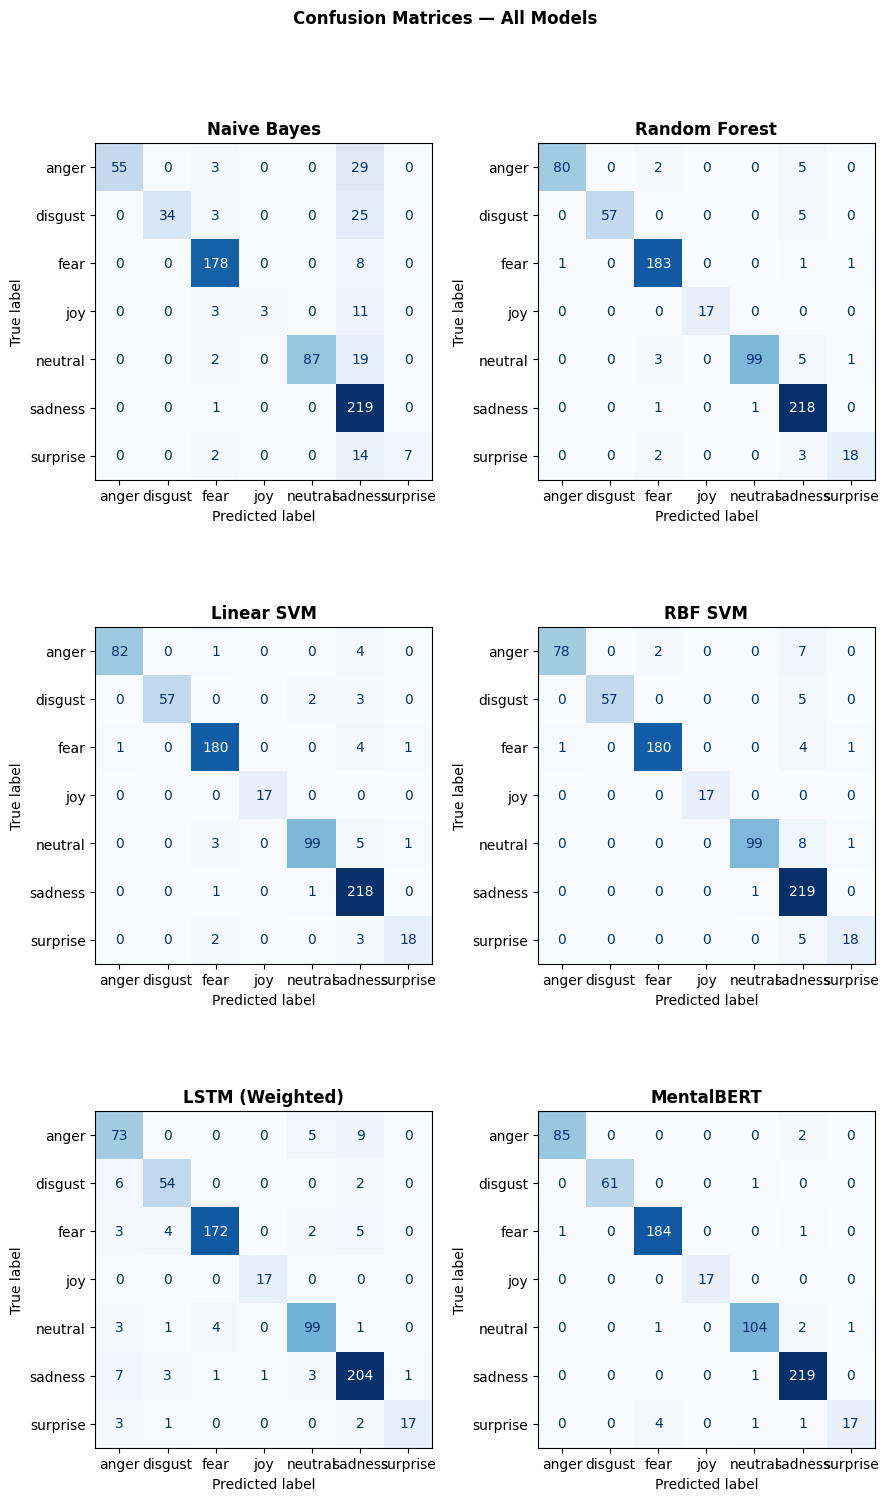

In [158]:
predictions = {
    'Naive Bayes':    Pred_y_nb,
    'Random Forest':  Pred_y_rf,
    'Linear SVM': best_linear.predict(X_test),
    'RBF SVM': best_rbf.predict(X_test),
    'LSTM (Weighted)':           pred_nn_lstm,
    'MentalBERT': y_pred_BERT
}

fig, axes = plt.subplots(3, 2, figsize=(9, 15))
axes = axes.flatten()

for ax, (name, preds) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, preds)
    ConfusionMatrixDisplay(cm, display_labels=le.classes_.astype(str)).plot(
        cmap='Blues', ax=ax, colorbar=False
    )
    ax.set_title(name, fontweight='bold')


plt.suptitle('Confusion Matrices — All Models', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()